# Exercício 1)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram
import librosa

In [4]:

fs = 4000
T = 5
t = np.linspace(0, T, int(fs*T), endpoint=False)


In [43]:

# =========================================================
# PLOT OSCILOGRAMA + ESPECTROGRAMA
# =========================================================

def plot_signal_and_spec(x, title):

    fig, ax = plt.subplots(2,1,figsize=(13,10),gridspec_kw={'height_ratios':[1,2]})

    # =====================================================
    # OSCILOGRAMA
    # =====================================================

    ax[0].plot(t, x, color='black', linewidth=0.08, antialiased=True, alpha=0.5)

    ax[0].set_title(f'Oscilograma - {title}')
    ax[0].set_xlabel('Tempo (s)')
    ax[0].set_ylabel('Amplitude')

    ax[0].set_xlim(0, T)

    # =====================================================
    # ESPECTROGRAMA
    # =====================================================

    f, tt, Sxx = spectrogram(x, fs, window='hann', nperseg=512, noverlap=420, mode='magnitude')

    im = ax[1].pcolormesh(
        tt,
        f,
        20*np.log10(Sxx + 1e-12),
        shading='nearest',
        cmap='seismic'
    )

    ax[1].set_title(f'Espectrograma - {title}')
    ax[1].set_xlabel('Tempo (s)')
    ax[1].set_ylabel('Frequência (Hz)')

    ax[1].set_ylim(0, 2000)

    cbar = fig.colorbar(im, ax=ax[1])
    cbar.set_label('dB')

    plt.tight_layout()

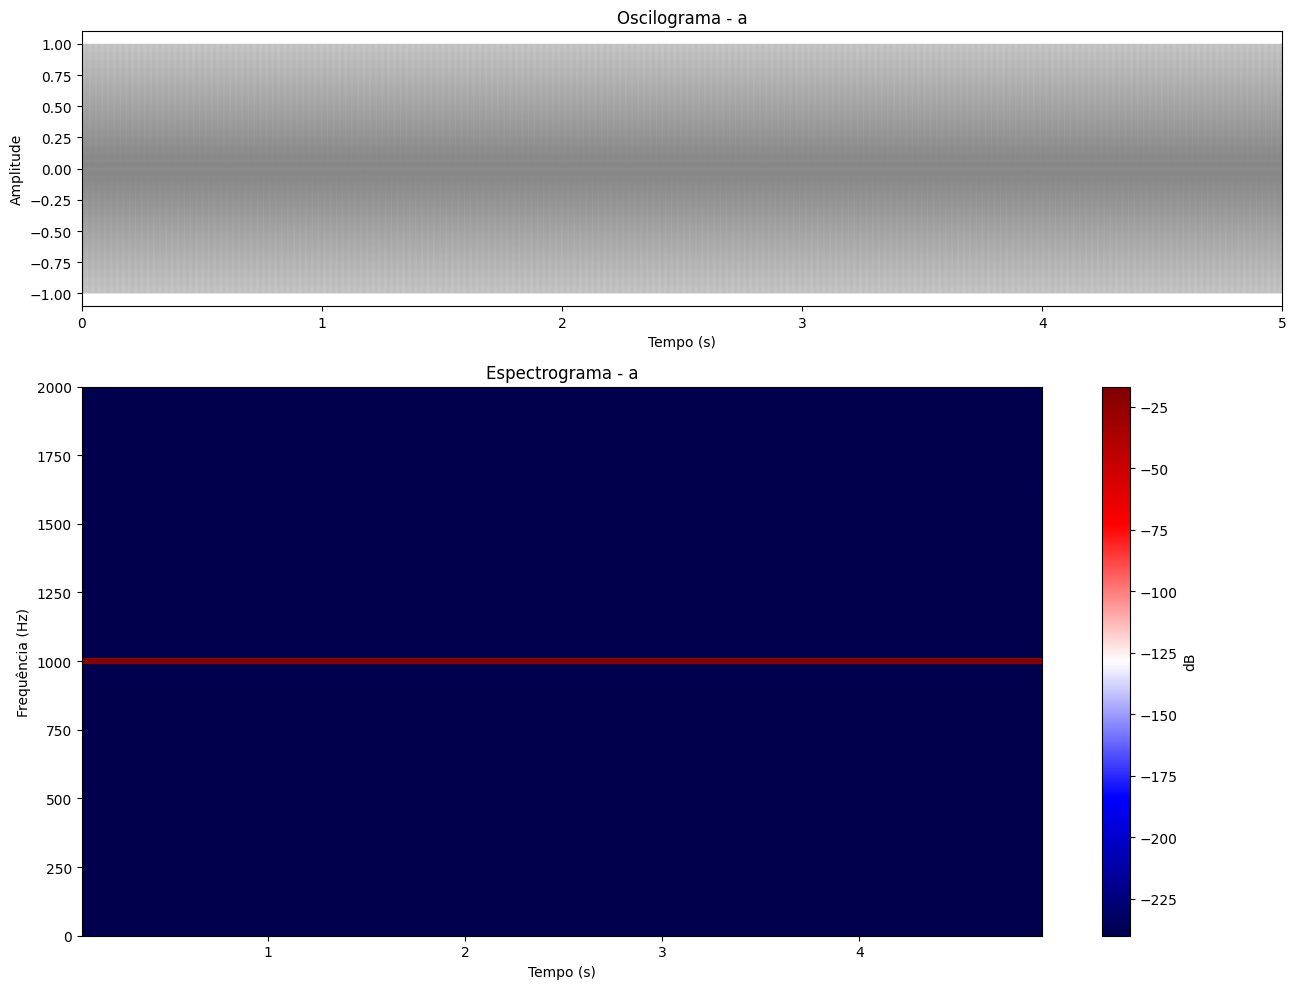

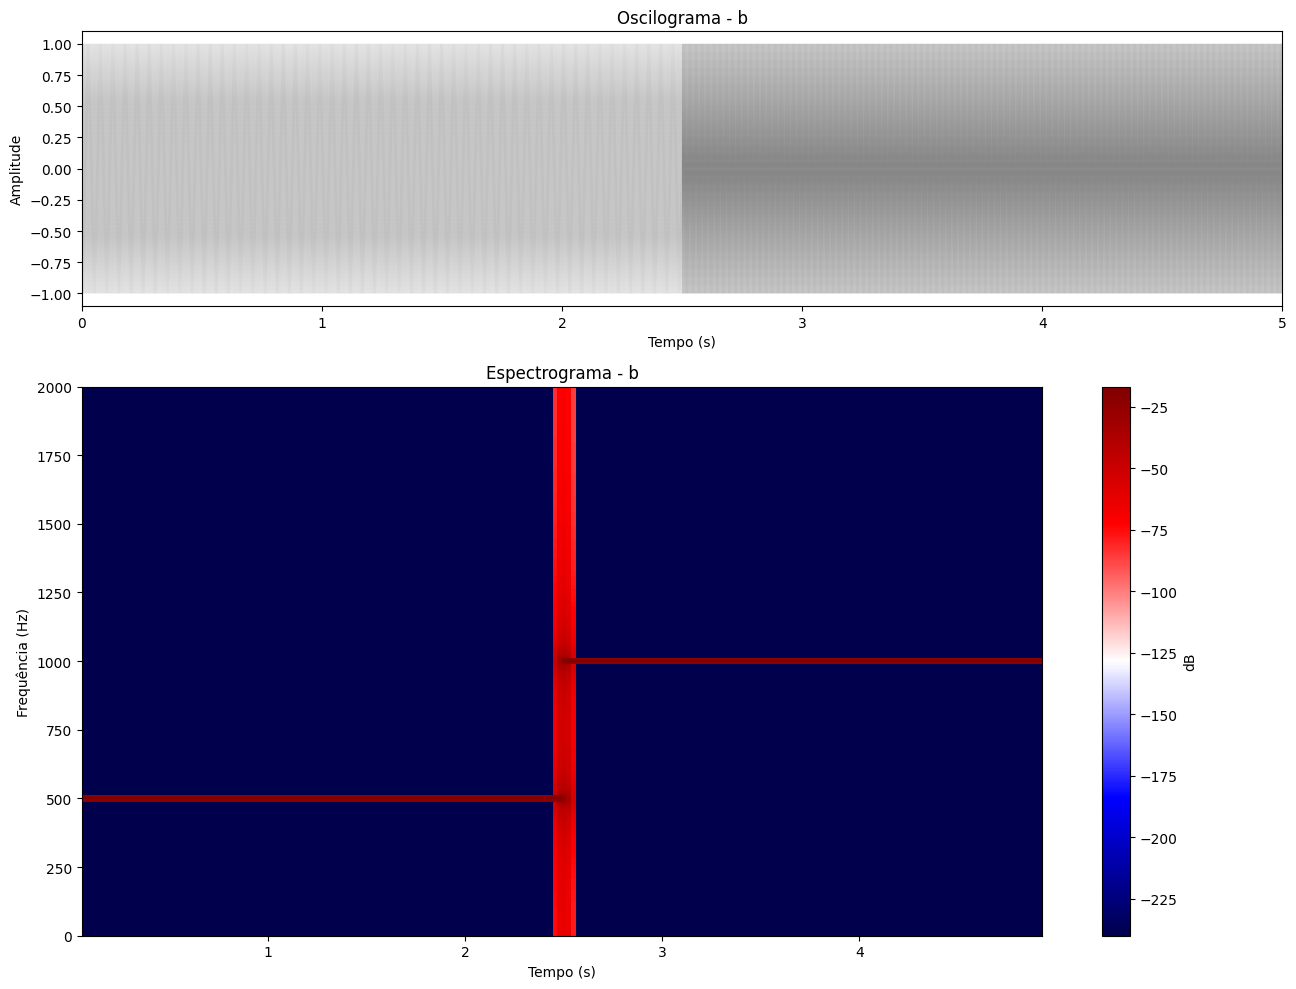

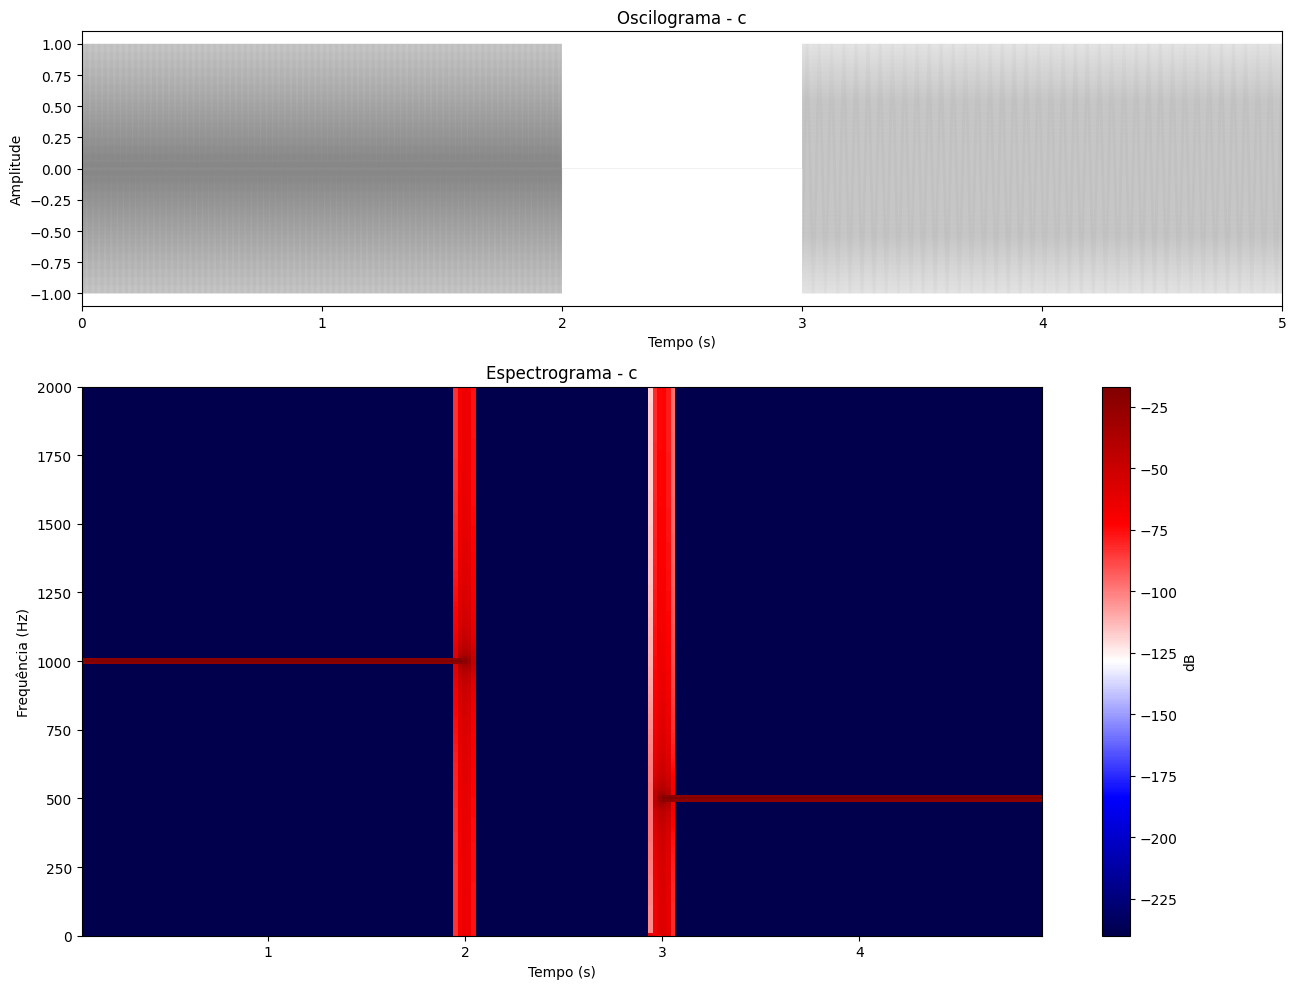

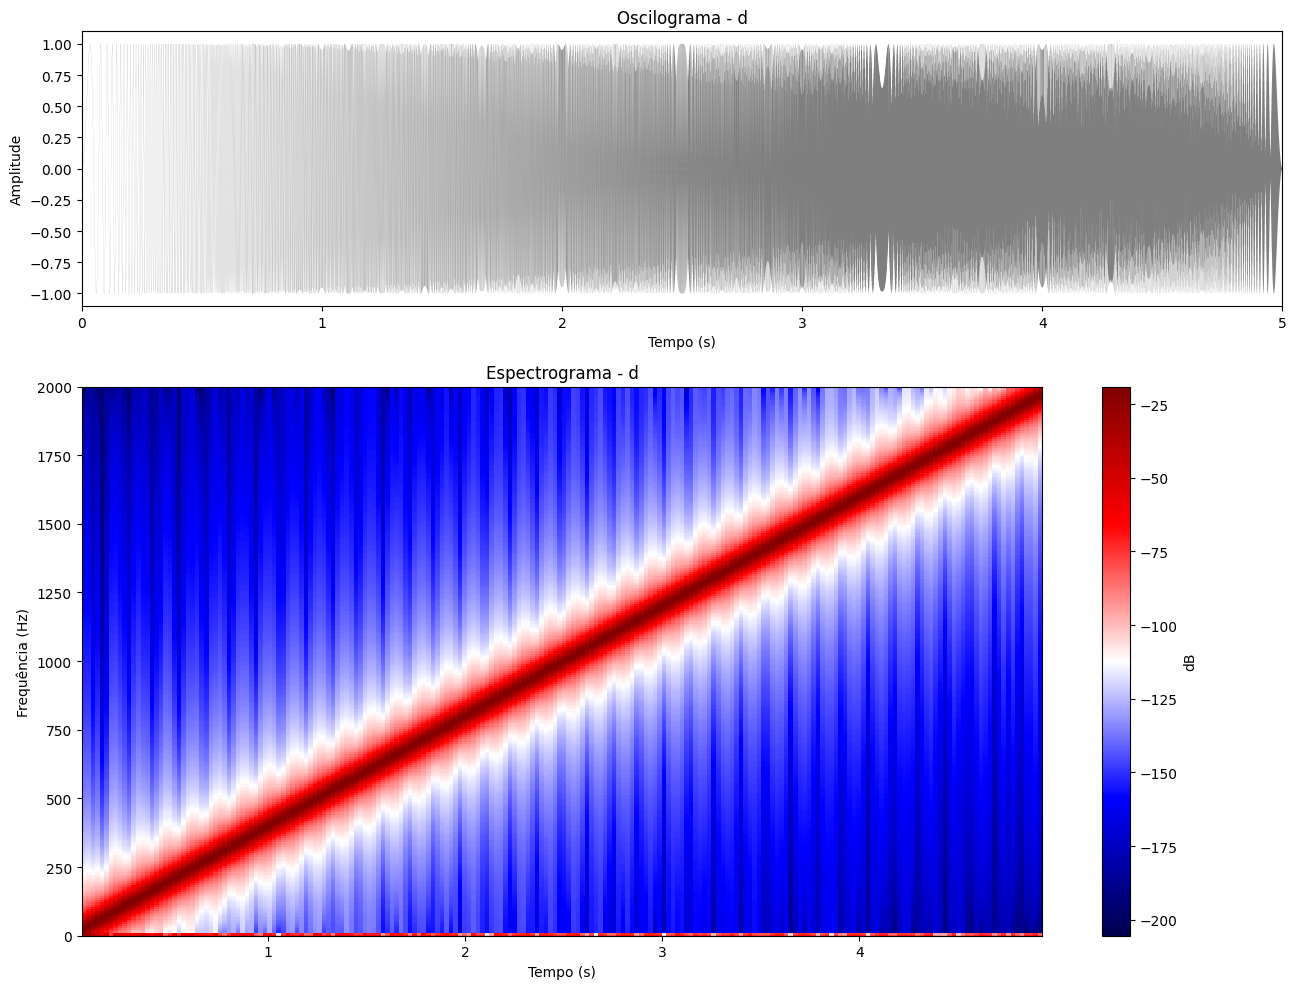

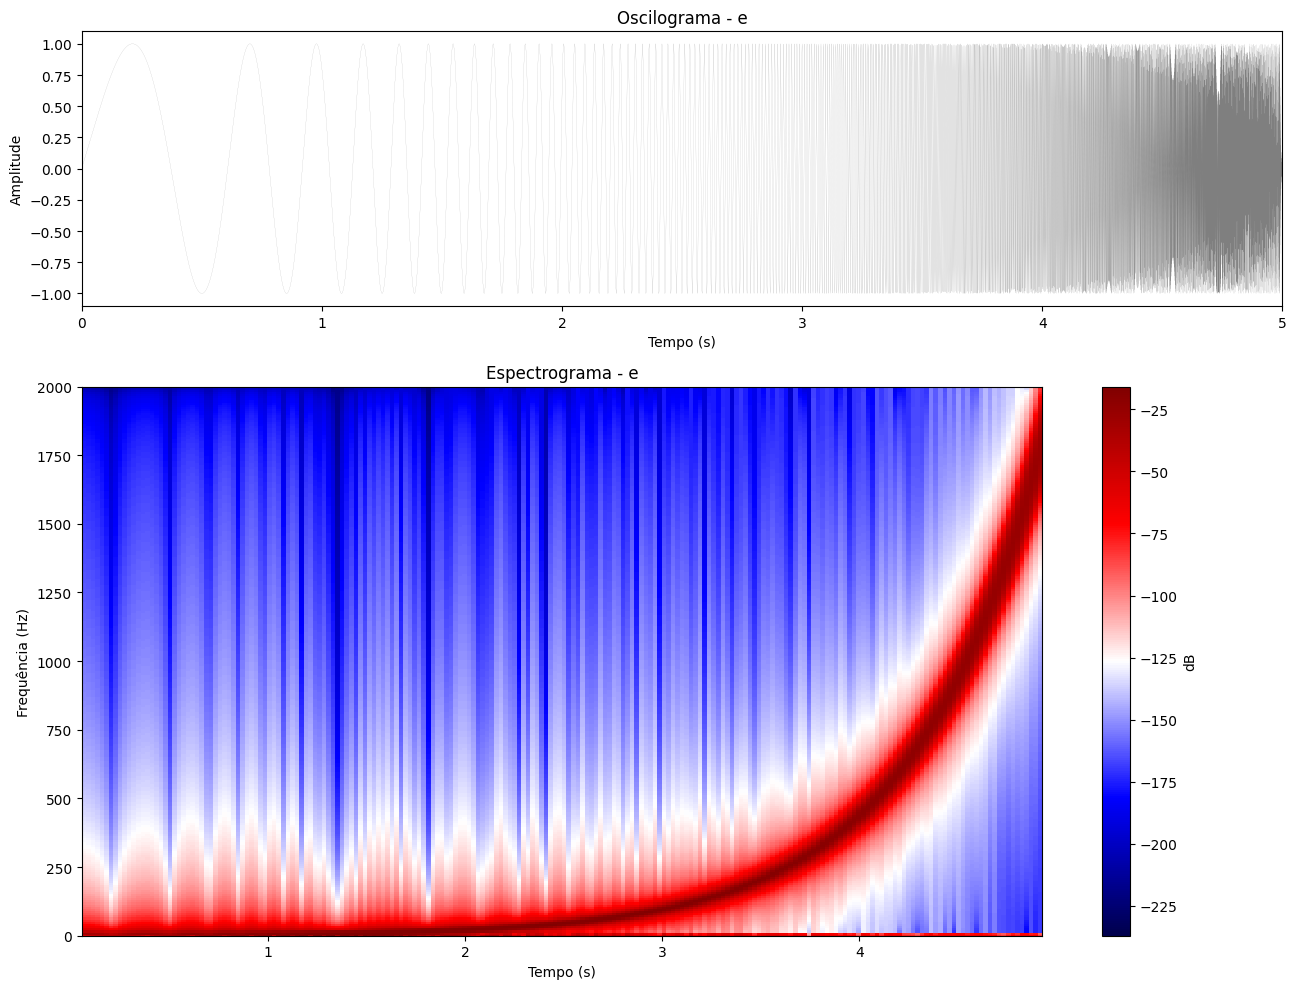

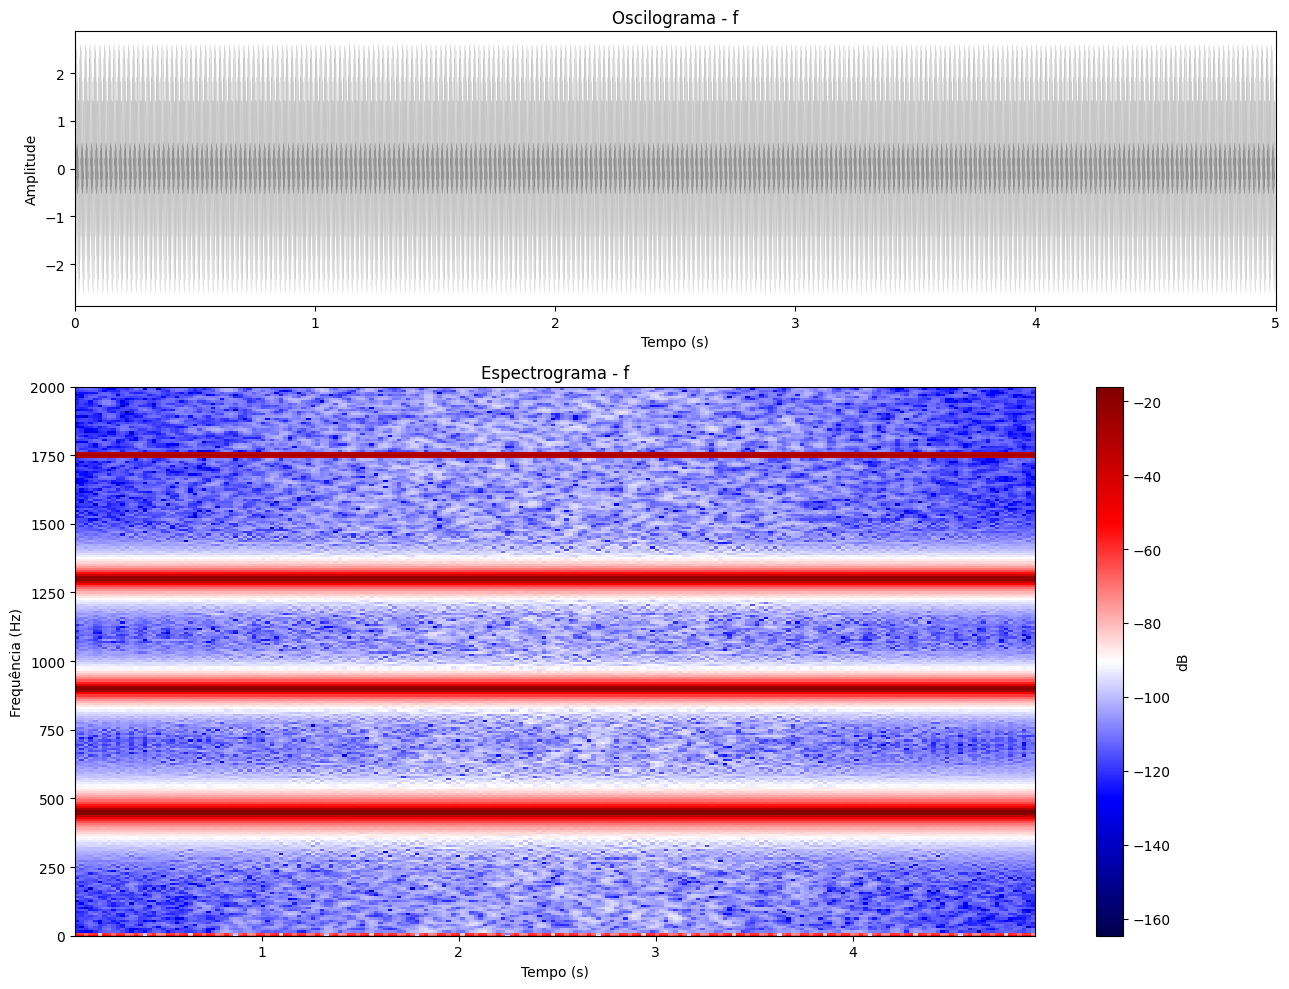

In [44]:


# =========================================================
# a) TOM FIXO
# =========================================================

def signal_a():
    return np.sin(2*np.pi*1000*t)

# =========================================================
# b) MUDANÇA BRUSCA
# =========================================================

def signal_b():

    x = np.zeros_like(t)

    idx = t < 2.5

    x[idx]  = np.sin(2*np.pi*500*t[idx])
    x[~idx] = np.sin(2*np.pi*1000*t[~idx])

    return x

# =========================================================
# c) TOM -> SILÊNCIO -> TOM
# =========================================================

def signal_c():

    x = np.zeros_like(t)

    a = t < 2
    b = (t >= 2) & (t < 3)
    c = t >= 3

    x[a] = np.sin(2*np.pi*1000*t[a])

    x[b] = 0

    x[c] = np.sin(2*np.pi*500*t[c])

    return x

# =========================================================
# d) CHIRP LINEAR
# =========================================================

def signal_d():

    f0 = 0
    f1 = 2000

    c = (f1 - f0)/T

    phase = 2*np.pi*(f0*t + (c/2)*t**2)

    return np.sin(phase)

# =========================================================
# e) CHIRP EXPONENCIAL
# =========================================================

def signal_e():

    f0 = 1
    f1 = 2000

    k = f1/f0

    phase = 2*np.pi*f0*(T*(k**(t/T)-1))/(np.log(k))

    return np.sin(phase)

# =========================================================
# f) HARMÔNICOS + RUÍDO VARIÁVEL
# =========================================================

def signal_f():

    # -----------------------------------------------------
    # harmônicos
    # baixa frequência -> maior amplitude
    # alta frequência -> menor amplitude
    # -----------------------------------------------------

    x = (
        1.2*np.sin(2*np.pi*450*t)   +
        0.9*np.sin(2*np.pi*900*t)   +
        0.6*np.sin(2*np.pi*1300*t)  +
        0.3*np.sin(2*np.pi*1750*t)
    )

    # -----------------------------------------------------
    # envelope temporal do ruído
    # mais forte no meio
    # mais fraco nas bordas
    # -----------------------------------------------------

    center = T/2

    sigma = T/4

    envelope = np.exp(
        -((t - center)**2)/(2*sigma**2)
    )

    # -----------------------------------------------------
    # ruído
    # -----------------------------------------------------

    noise = 0.0005 * envelope * np.random.randn(len(t))

    return x + noise

# =========================================================
# GERAR
# =========================================================

signals = [
    (signal_a(), 'a'),
    (signal_b(), 'b'),
    (signal_c(), 'c'),
    (signal_d(), 'd'),
    (signal_e(), 'e'),
    (signal_f(), 'f'),
]

for x, name in signals:
    plot_signal_and_spec(x, name)

plt.show()

---

# Exercício 3)

In [123]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd
from matplotlib.patches import Patch


In [91]:
x_had, sr = librosa.load('SA1.wav', sr=16000, mono=True)
ipd.Audio(x_had, rate=sr)

In [92]:
x_had.shape[0]

46797

In [93]:
sr

16000

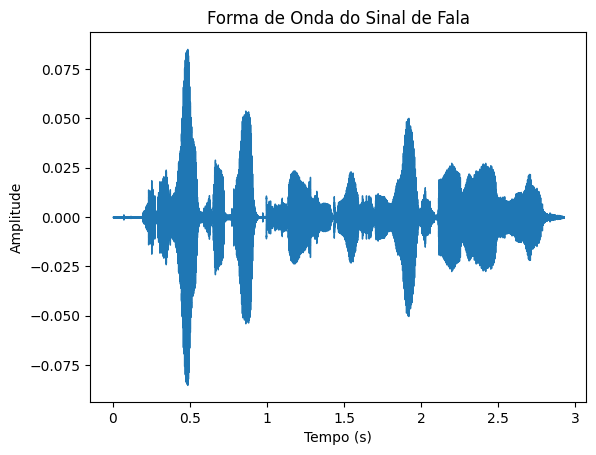

In [94]:
librosa.display.waveshow(x_had, sr=sr)
plt.title('Forma de Onda do Sinal de Fala')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.show()

In [95]:
# Definir durações
segment_duration = 20e-3  # 20 ms
hop_duration = 10e-3       # 10 ms (50% de sobreposição)

# Converter tempo em número de amostras
frame_length = int(segment_duration * sr)
hop_length = int(hop_duration * sr)

print(f"Comprimento do quadro (em amostras): {frame_length}")
print(f"Salto (em amostras): {hop_length}")

# Preenchimento para indexação centralizada
x_had_pad = np.pad(x_had, (frame_length//2, frame_length//2), 'constant', constant_values=(0,0))

# Segmentar o sinal
frames = librosa.util.frame(x_had_pad, frame_length=frame_length, hop_length=hop_length)
print(f"Forma da matriz de quadros (comprimento_quadro, num_quadros): {frames.shape}")

Comprimento do quadro (em amostras): 320
Salto (em amostras): 160
Forma da matriz de quadros (comprimento_quadro, num_quadros): (320, 293)


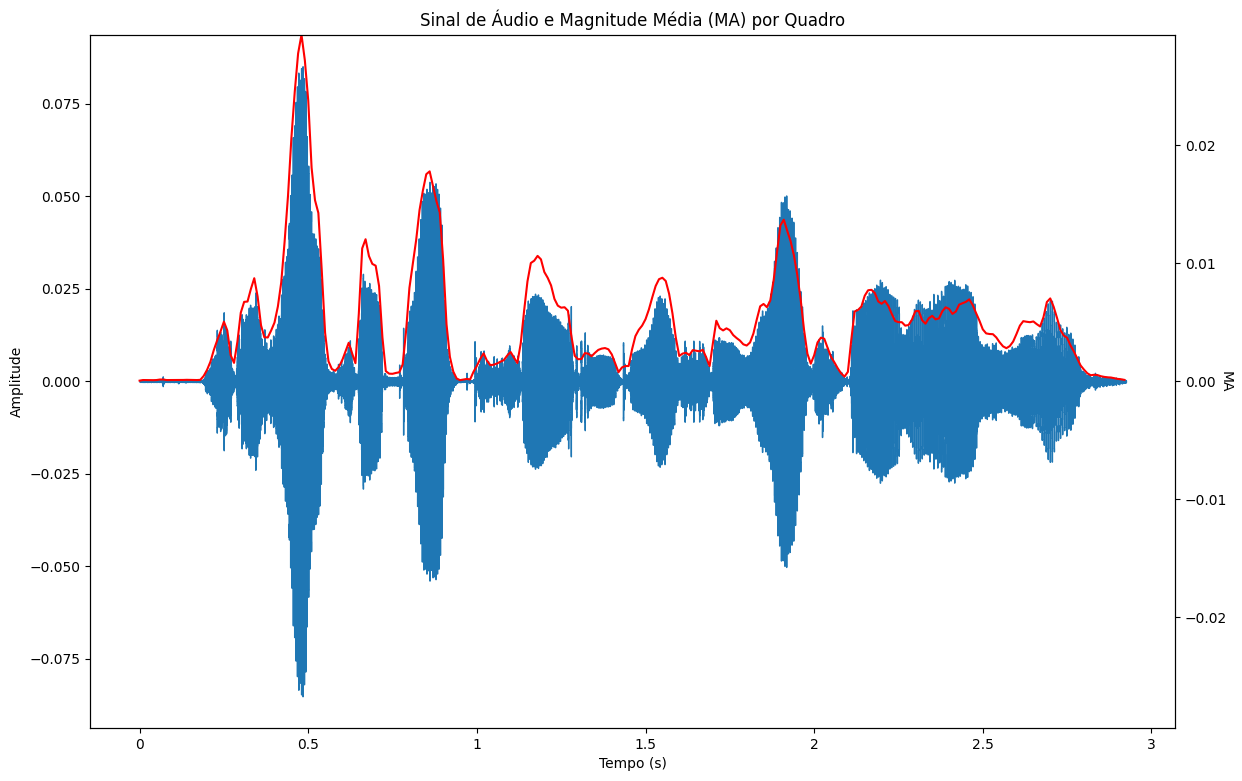

In [100]:
# Calcular a Magnitude Média para cada quadro
magnitude = np.mean(np.abs(frames), axis=0)

# Criar um eixo de tempo para os quadros
t_frame_ma = np.arange(magnitude.shape[0]) * hop_duration

# Visualizar o sinal e a Magnitude Média
fig = plt.figure(figsize=(14, 9))
ax1 = fig.subplots()
ax2 = ax1.twinx()
librosa.display.waveshow(x_had, sr=sr, ax=ax1)
ax1.set_xlabel("Tempo (s)")
ax1.set_ylabel('Amplitude')
ax2.plot(t_frame_ma, magnitude, '-r', label='MA')
ax2.set_ylim(ymin=-np.max(magnitude), ymax=np.max(magnitude))
ax2.set_ylabel('MA', rotation=-90)
plt.title('Sinal de Áudio e Magnitude Média (MA) por Quadro')
plt.show()

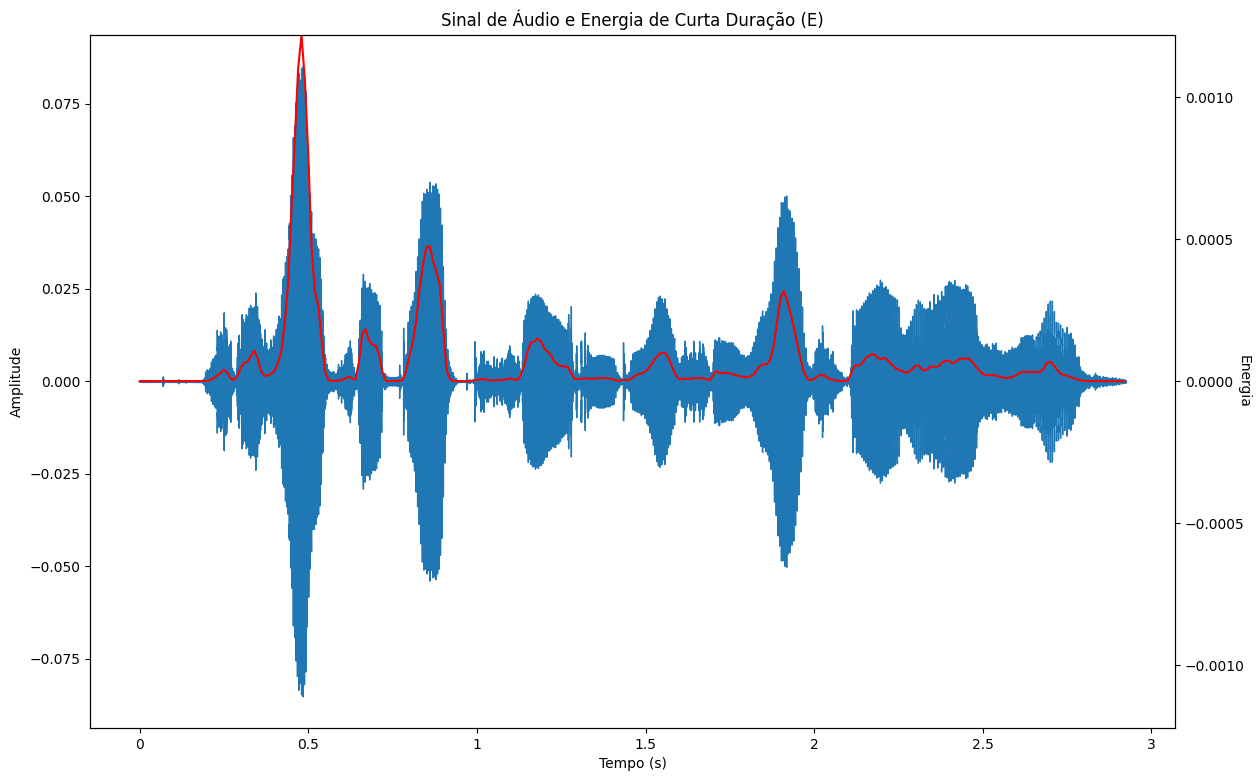

In [103]:
energy = np.mean(frames**2, axis=0)
t_frame_e = np.arange(energy.shape[0]) * hop_duration

fig = plt.figure(figsize=(14, 9))
ax1 = fig.subplots()
ax2 = ax1.twinx()
librosa.display.waveshow(x_had, sr=sr, ax=ax1)
ax1.set_xlabel("Tempo (s)")
ax1.set_ylabel('Amplitude')
ax2.plot(t_frame_e, energy, '-r', label='Energia')
ax2.set_ylim(ymin=-np.max(energy), ymax=np.max(energy))
ax2.set_ylabel('Energia', rotation=-90)
plt.title('Sinal de Áudio e Energia de Curta Duração (E)')
plt.show()

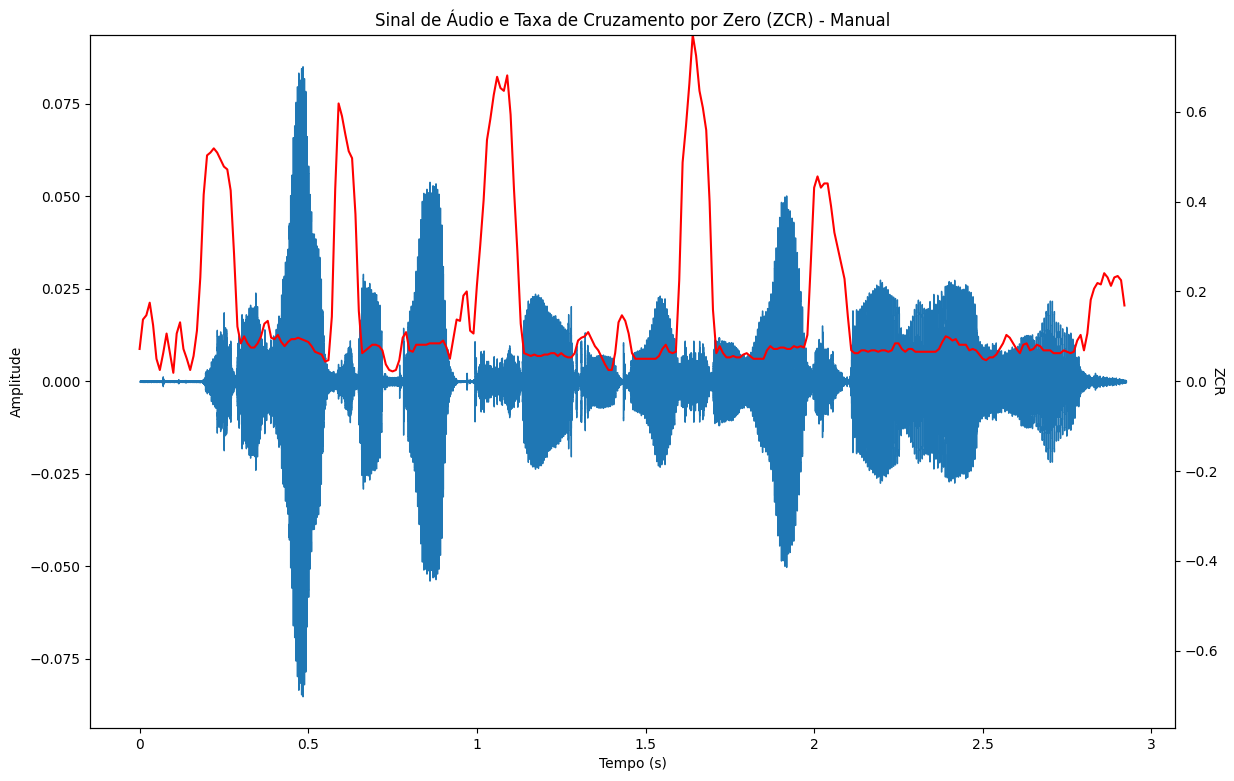

In [107]:
# Implementação manual da ZCR
def sign_mod(x):
    return 1 if x >= 0 else -1

def zcr(frames):
    num_frames = frames.shape[1]
    frame_len = frames.shape[0]
    zcr = np.zeros(num_frames)
    for j in range(num_frames):
        for i in range(1, frame_len):
            zcr[j] += np.abs(sign_mod(frames[i, j]) - sign_mod(frames[i-1, j]))
    return zcr / (2 * frame_len)

zcr_manual_values = zcr(frames)
t_frame_zcr = np.arange(zcr_manual_values.shape[0]) * hop_duration

# Equivalentemente 
# Cálculo da ZCR usando a função do librosa
# zcr_librosa = librosa.feature.zero_crossing_rate(y=x_had, frame_length=frame_length, hop_length=hop_length, center=True)
# zcr_librosa = np.squeeze(zcr_librosa)
# t_frame_librosa = np.arange(zcr_librosa.shape[0]) * hop_duration

# Visualização da ZCR calculada manualmente
fig = plt.figure(figsize=(14, 9))
ax1 = fig.subplots()
ax2 = ax1.twinx()
librosa.display.waveshow(x_had, sr=sr, ax=ax1)
ax1.set_xlabel("Tempo (s)")
ax1.set_ylabel('Amplitude')
ax2.plot(t_frame_zcr, zcr_manual_values, '-r', label='ZCR (manual)')
ax2.set_ylim(ymin=-np.max(zcr_manual_values), ymax=np.max(zcr_manual_values))
ax2.set_ylabel('ZCR', rotation=-90)
plt.title('Sinal de Áudio e Taxa de Cruzamento por Zero (ZCR) - Manual')
plt.show()

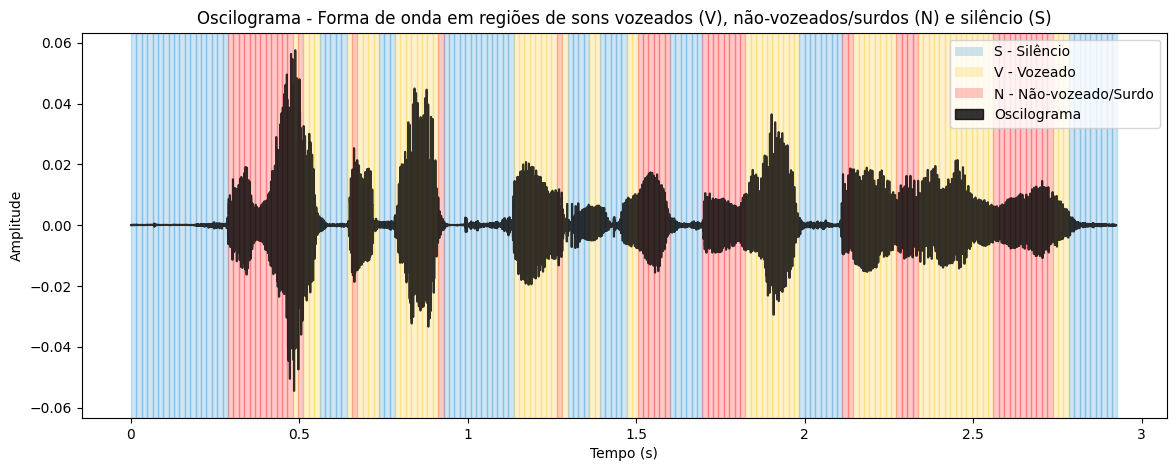

In [184]:
labels = []
for e, z in zip(energy, zcr_manual_values):
    if e < 0.01*np.max(energy): # 1% do valor energia máximo
        labels.append("S")
    else:
        if z < 0.1: # usualmente para frequências de 8kHz a 16kHz (áudios de voz de humanos)
            labels.append("V")
        else:
            labels.append("N")

plt.figure(figsize=(14,5))
librosa.display.waveshow(x_had, sr=sr, color='black', alpha=0.8, label='Oscilograma')
for t, lab in zip(t_frame_e, labels):
    color = {"S": "#1485CC", "V": "#FEC20B", "N": "#FF0001"}[lab]
    plt.axvspan(t, t + hop_duration, color=color, alpha=0.21)

# Custom legend
legend_patches = [
    Patch(facecolor="#1485CC", alpha=0.21, label="S - Silêncio"),
    Patch(facecolor="#FEC20B", alpha=0.21, label="V - Vozeado"),
    Patch(facecolor="#FF0001", alpha=0.21, label="N - Não-vozeado/Surdo"),
]

plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.title(
    "Oscilograma - Forma de onda em regiões de sons "
    "vozeados (V), não-vozeados/surdos (N) e silêncio (S)"
)

plt.legend(handles=legend_patches + plt.gca().get_legend_handles_labels()[0:1][0])
plt.show()

---

# Exercício 4)

## a)

In [190]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd
from matplotlib.patches import Patch
# Encontrar os picos da autocorrelação
from scipy.signal import find_peaks
from scipy.signal import lfilter
from scipy.linalg import toeplitz




In [145]:
# Abrindo o arquivo monofônico com frequência de amostragem com 2kHz
x_had, sr = librosa.load('SA1.wav', sr=2000, mono=True)

In [179]:
# Definir durações
segment_duration = 32e-3  # 32 ms
hop_duration = 16e-3       # 16 ms (50% de sobreposição)

# Converter tempo em número de amostras
frame_length = int(segment_duration * sr)
hop_length = int(hop_duration * sr)

print(f"Comprimento do quadro (em amostras): {frame_length}")
print(f"Salto (em amostras): {hop_length}")

# Preenchimento para indexação centralizada
x_had_pad = np.pad(x_had, (frame_length//2, frame_length//2), 'constant', constant_values=(0,0))

# Segmentar o sinal
frames = librosa.util.frame(x_had_pad, frame_length=frame_length, hop_length=hop_length)
print(f"Forma da matriz de quadros (comprimento_quadro, num_quadros): {frames.shape}")

Comprimento do quadro (em amostras): 64
Salto (em amostras): 32
Forma da matriz de quadros (comprimento_quadro, num_quadros): (64, 183)


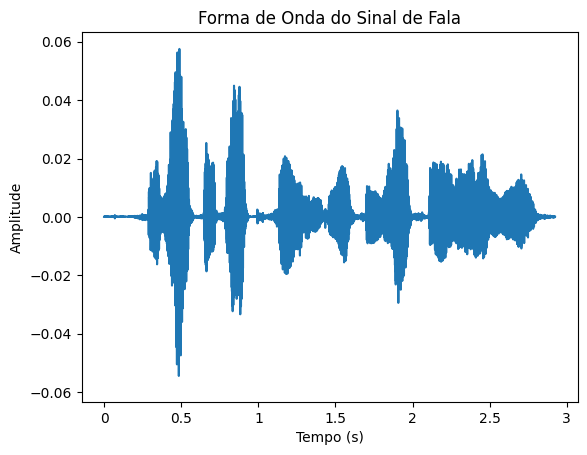

In [183]:
librosa.display.waveshow(x_had, sr=sr)
plt.title('Forma de Onda do Sinal de Fala')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.show()

## b)

Quantidade de quadros: 183


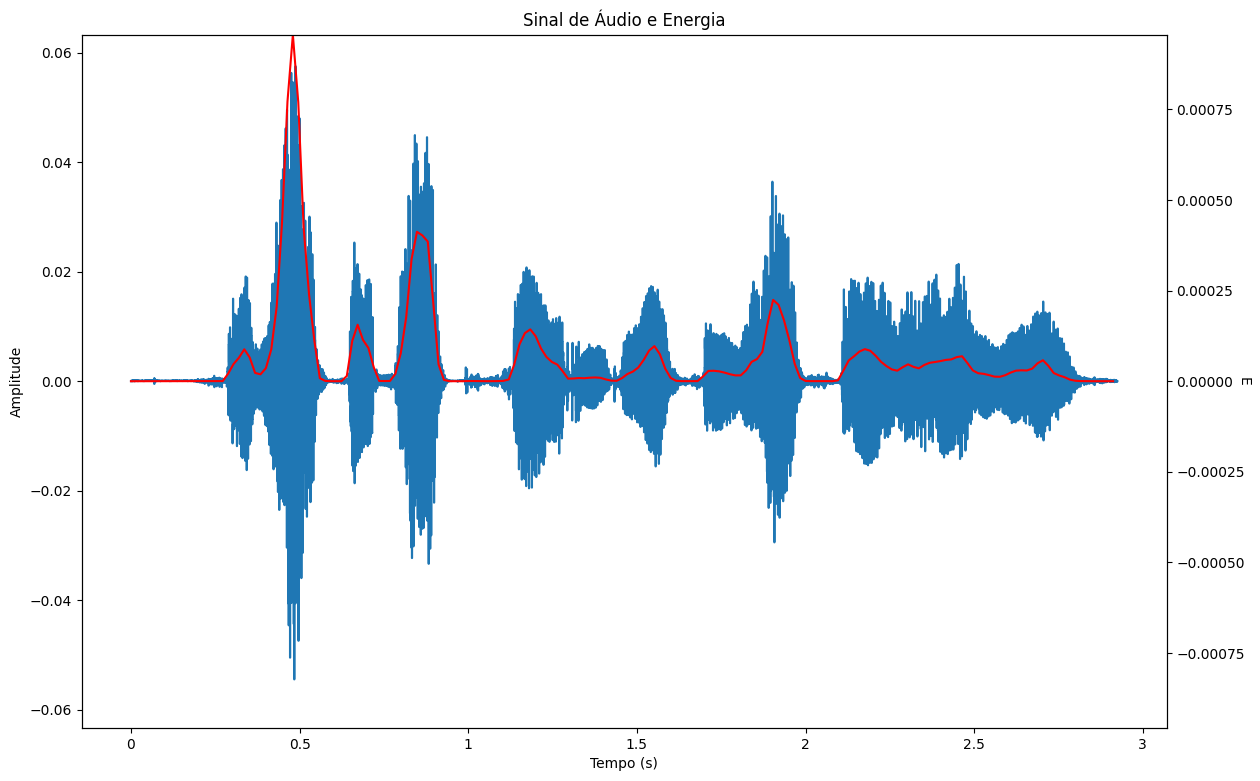

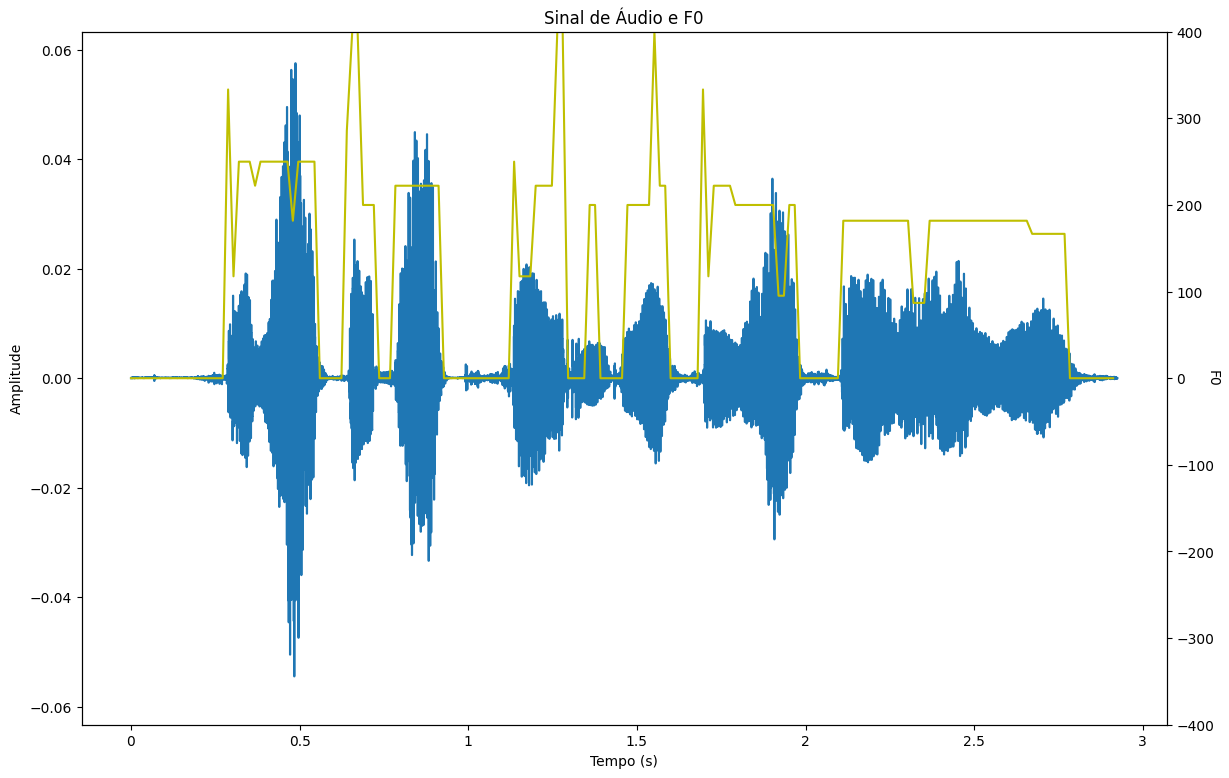

In [185]:
# Implementando o algoritmo da autocorrelação
F0_MIN = 40
F0_MAX = 400

LAG_MIN = sr // F0_MAX
LAG_MAX = sr // F0_MIN

# Calculando a energia 
energy = np.mean(frames**2, axis=0) # eixo 0 em numpy são as colunas (que representam o segmento)
print('Quantidade de quadros:', len(energy))
t_frame_e = np.arange(energy.shape[0]) * hop_duration

f0 = []
for idx, quadro in enumerate(frames.T): #transpor para coletar dentro de cada quadro
    s = quadro
    R = librosa.autocorrelate(s)
    r = R[LAG_MIN:LAG_MAX]
    lag = np.argmax(r) + LAG_MIN
    f0.append(sr/lag) # F0

    # peaks, _ = find_peaks(R, height=0)
    # # Visualizar a autocorrelação com os picos marcados
    # plt.figure(figsize=(10, 4))
    # plt.plot(R)
    # plt.plot(peaks, R[peaks], 'x', label='Picos')
    # plt.title('Autocorrelação com Picos')
    # plt.xlabel('Lag (amostras)')
    # plt.ylabel('R[m]')
    # plt.legend()
    # plt.grid(True)
    # plt.show()

    # break


# Visualização da Energia
fig = plt.figure(figsize=(14, 9))
ax1 = fig.subplots()
ax2 = ax1.twinx()
librosa.display.waveshow(x_had, sr=sr, ax=ax1)
ax1.set_xlabel("Tempo (s)")
ax1.set_ylabel('Amplitude')
ax2.plot(t_frame_e, energy, '-r', label='Energia')
ax2.set_ylim(ymin=-np.max(energy), ymax=np.max(energy))
ax2.set_ylabel('E', rotation=-90)
plt.title('Sinal de Áudio e Energia')
plt.show()

# Visualização da F0 pela autocorrelação
fig = plt.figure(figsize=(14, 9))
ax1 = fig.subplots()
ax2 = ax1.twinx()
librosa.display.waveshow(x_had, sr=sr, ax=ax1)
ax1.set_xlabel("Tempo (s)")
ax1.set_ylabel('Amplitude')
ax2.plot(t_frame_e, np.where(energy > 0.01*np.max(energy), f0, 0), '-y', label='F0')
ax2.set_ylim(ymin=-np.max(f0), ymax=np.max(f0))
ax2.set_ylabel('F0', rotation=-90)
plt.title('Sinal de Áudio e F0')
plt.show()

## c)

In [193]:
LPC_ORDER = 4

f0_sift = []
for idx, quadro in enumerate(frames.T):
    a = librosa.lpc(quadro, order=LPC_ORDER)
    residual = lfilter(a, [1], quadro) # H(z) = A(z)
    R = librosa.autocorrelate(residual)

    r = R[LAG_MIN:LAG_MAX]

    # lag do pico máximo
    lag = np.argmax(r) + LAG_MIN

    # frequência fundamental
    f0_est = sr / lag

    f0_sift.append(f0_est)


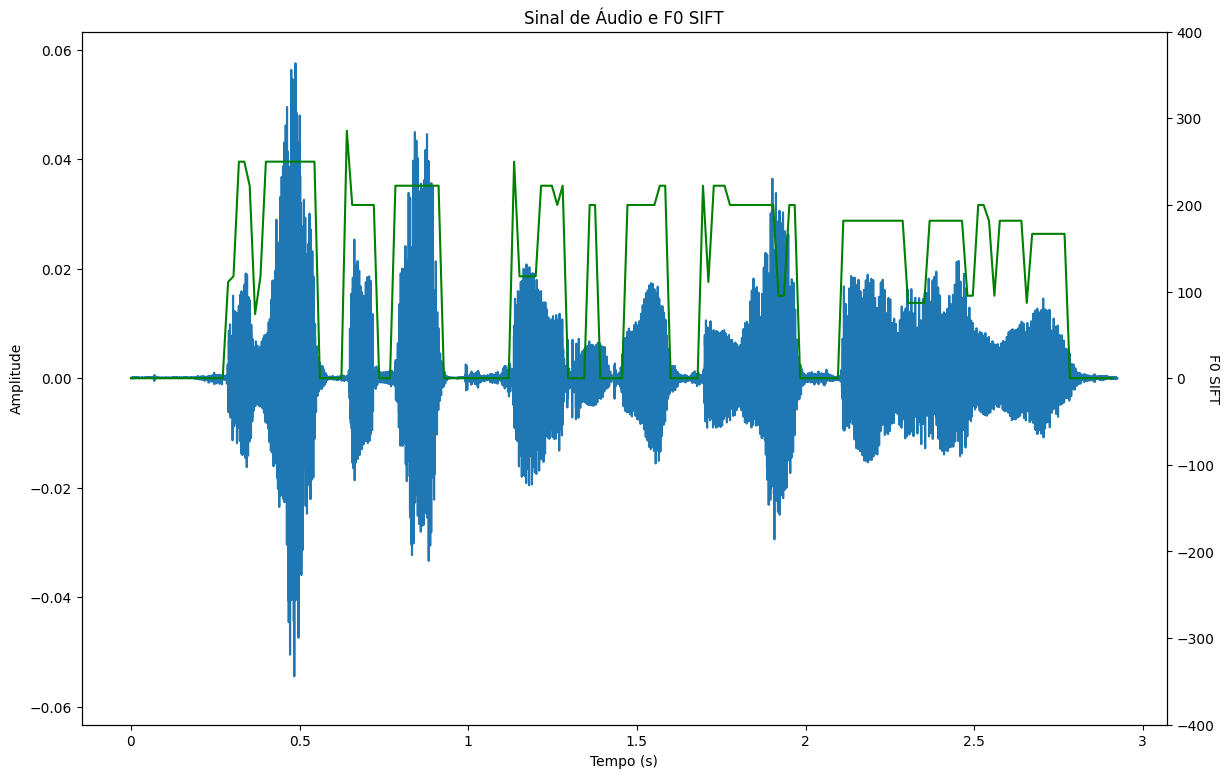

In [197]:

# Visualização da F0 pela autocorrelação
fig = plt.figure(figsize=(14, 9))
ax1 = fig.subplots()
ax2 = ax1.twinx()
librosa.display.waveshow(x_had, sr=sr, ax=ax1)
ax1.set_xlabel("Tempo (s)")
ax1.set_ylabel('Amplitude')
ax2.plot(t_frame_e, np.where(energy > 0.01*np.max(energy), f0_sift, 0), '-g', label='F0 SIFT')
ax2.set_ylim(ymin=-np.max(f0_sift), ymax=np.max(f0_sift))
ax2.set_ylabel('F0 SIFT', rotation=-90)
plt.title('Sinal de Áudio e F0 SIFT')
plt.show()

## d)

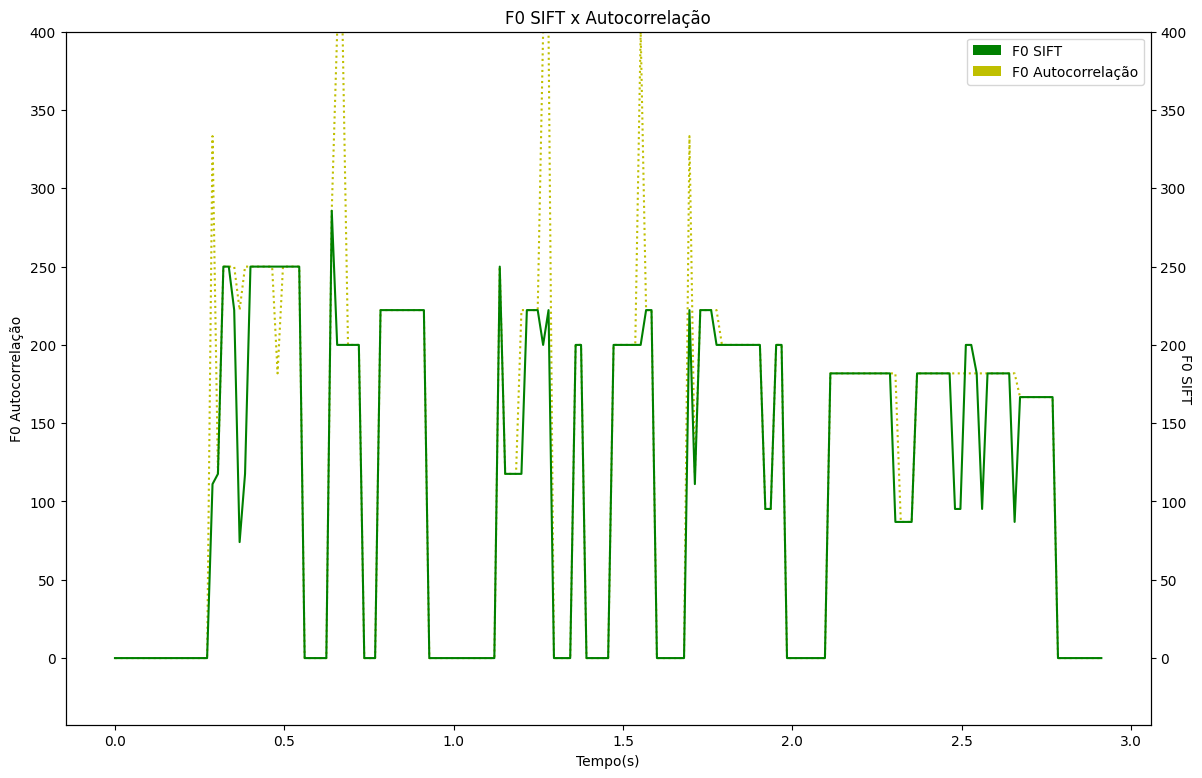

In [205]:

# Visualização da F0 pela autocorrelação
fig = plt.figure(figsize=(14, 9))
ax1 = fig.subplots()
ax2 = ax1.twinx()

legend_patches = [
    Patch(facecolor="g", alpha=1, label="F0 SIFT"),
    Patch(facecolor="y", alpha=1, label="F0 Autocorrelação"),
]


plt.legend(handles=legend_patches + plt.gca().get_legend_handles_labels()[0:1][0])

ax1.set_xlabel("Tempo(s)")
ax1.plot(t_frame_e, np.where(energy > 0.01*np.max(energy), f0, 0), ':y', label='F0 Autocorrelação')
ax1.set_ylim(ymin=-np.min(f0+f0_sift), ymax=np.max(f0+f0_sift))
ax1.set_ylabel('F0 Autocorrelação')
ax2.plot(t_frame_e, np.where(energy > 0.01*np.max(energy), f0_sift, 0), '-g', label='F0 SIFT')
ax2.set_ylim(ymin=-np.min(f0+f0_sift), ymax=np.max(f0+f0_sift))
ax2.set_ylabel('F0 SIFT', rotation=-90)
plt.title('F0 SIFT x Autocorrelação')
plt.show()

Portanto, percebe-se que a frequência fundamental F0 calculada no método de SIFT tende a reduzir a influência dos formantes, enquanto na autocorrelação direta, os formantes do trato vocal influenciam fortemente os picos da função.